<a href="https://colab.research.google.com/github/lambforwork-source/BTAP-NHOM-4-KHDL/blob/main/KHDL_NH%C3%93M_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [8]:
df = pd.read_csv('/content/adult.csv')

In [9]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
# 1.1. Chọn các cột kiểu số để kiểm tra outliers
numeric_cols = df.select_dtypes(include=['int64']).columns

# 1.2. Định nghĩa hàm xử lý outliers bằng IQR
def remove_outliers_iqr(df, columns):
    df_final = df.copy()
    for col in columns:
        Q1 = df_final[col].quantile(0.25)
        Q3 = df_final[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Lọc dữ liệu nằm trong khoảng [lower_bound, upper_bound]
        df_final = df_final[(df_final[col] >= lower_bound) & (df_final[col] <= upper_bound)]

    return df_final

# 1.3. Áp dụng hàm vào dataframe hiện tại
df_clean = remove_outliers_iqr(df, numeric_cols)

# 1.4. Kiểm tra lại kích thước dữ liệu sau khi lọc
print(f"Dữ liệu sau khi làm sạch. Số dòng gốc: {len(df)}, Số dòng sạch: {len(df_clean)} [cite: 37]")

Dữ liệu sau khi làm sạch. Số dòng gốc: 32561, Số dòng sạch: 19004 [cite: 37]


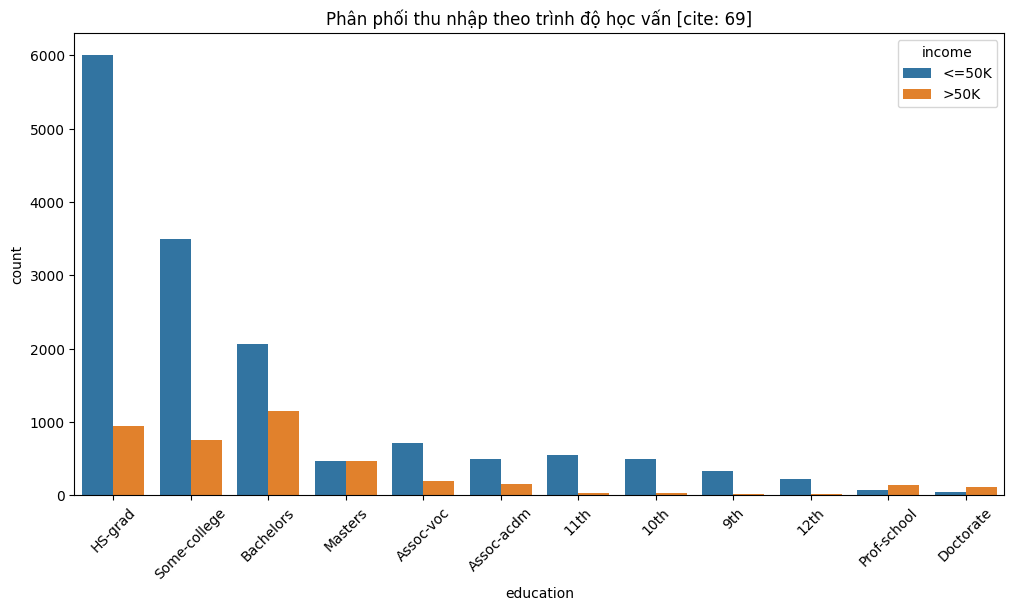

In [13]:
# 2.1 Kiểm định giả thuyết: Trình độ học vấn có ảnh hưởng đến thu nhập? [cite: 62]
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='education', hue='income', order=df_clean['education'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Phân phối thu nhập theo trình độ học vấn [cite: 69]")
plt.show()

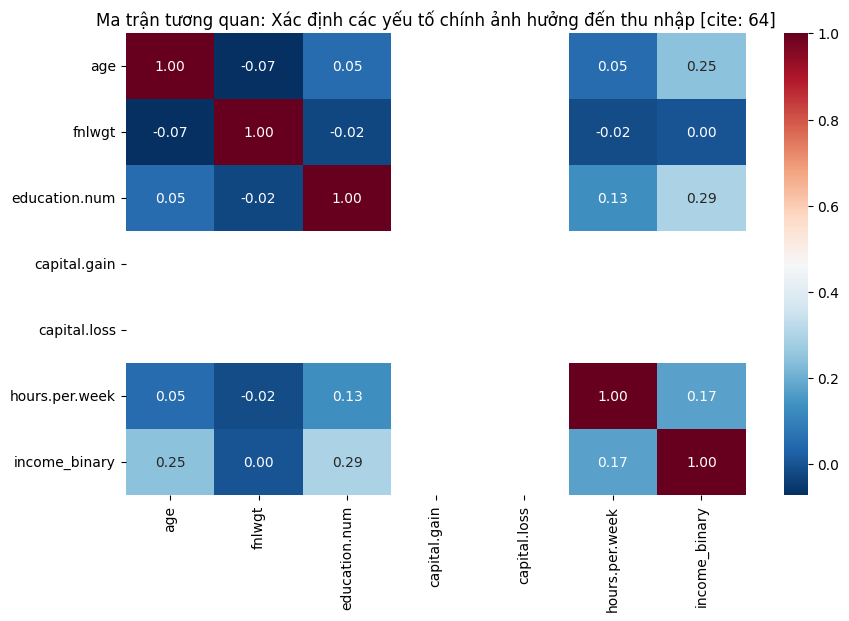

In [14]:
# 2.2 Phân tích tương quan [cite: 64]
# Chuyển đổi mục tiêu 'income' sang dạng số (0 và 1) để tính toán
# Strip khoảng trắng trong cột income phòng trường hợp CSV có padding
df_clean['income'] = df_clean['income'].str.strip()
df_clean['income_binary'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

plt.figure(figsize=(10, 6))
numeric_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title("Ma trận tương quan: Xác định các yếu tố chính ảnh hưởng đến thu nhập [cite: 64]")
plt.show()



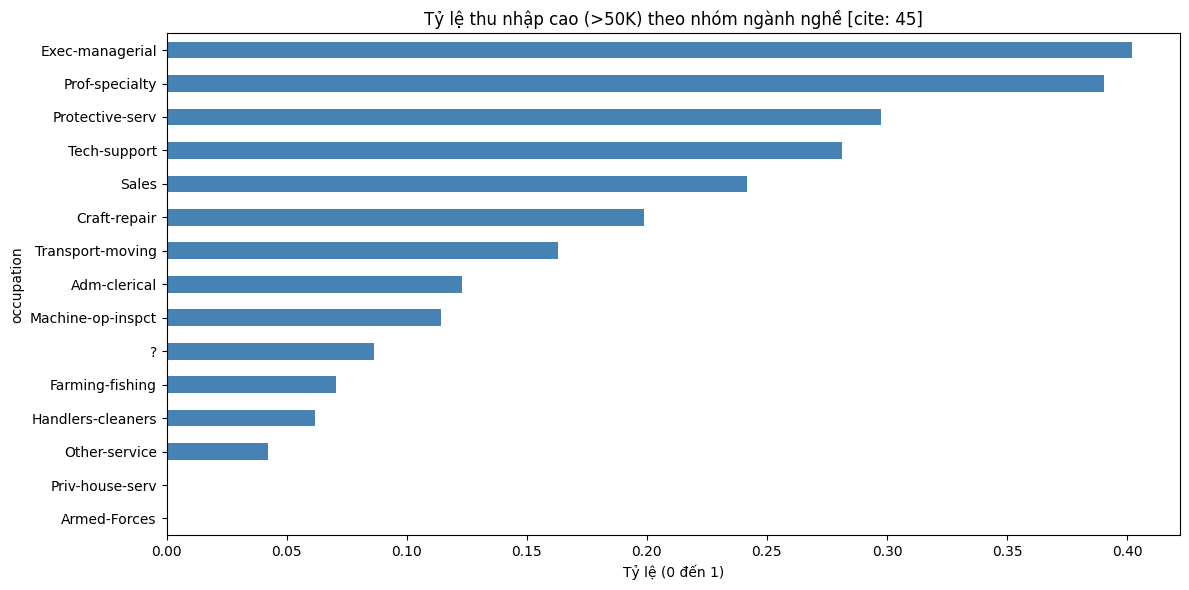

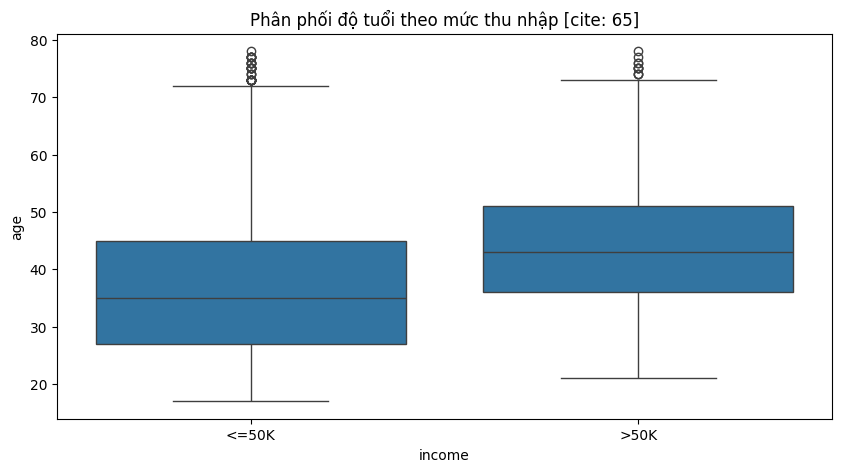

In [15]:
# 3.1 Biểu đồ cột: Nghề nghiệp vs Thu nhập [cite: 69]
occupation_income = df_clean.groupby('occupation')['income_binary'].mean().sort_values()
plt.figure(figsize=(12, 6))
occupation_income.plot(kind='barh', color='steelblue')
plt.title("Tỷ lệ thu nhập cao (>50K) theo nhóm ngành nghề [cite: 45]")
plt.xlabel("Tỷ lệ (0 đến 1)")
plt.tight_layout()
plt.show()
# DIỄN GIẢI: Nhóm quản lý (Exec-managerial) có khả năng đạt mức thu nhập cao nhất[cite: 46].

# 3.2 Biểu đồ hộp (Boxplot): Độ tuổi vs Thu nhập [cite: 65, 70]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='income', y='age')
plt.title("Phân phối độ tuổi theo mức thu nhập [cite: 65]")
plt.show()
# DIỄN GIẢI: Những người thu nhập cao thường có độ tuổi trung bình lớn hơn, cho thấy kinh nghiệm là yếu tố then chốt.